# Análise dos Microdados do SISVAN em Recife (2023)
## Pipeline de preparação, clusterização de unidades de saúde e inferência estatística

Este notebook apresenta um fluxo reprodutível para filtrar os microdados do SISVAN referentes ao município do Recife, tratar inconsistências, construir um escore nutricional, agregar indicadores por unidade de saúde e identificar perfis assistenciais por meio de clusterização com K-Means. Ao final, são aplicados testes de hipótese para comparar os grupos identificados e discutir sua interpretação estatística.

## 1. Contextualização do Problema e dos Dados

O Sistema de Vigilância Alimentar e Nutricional (SISVAN) é a estratégia do Sistema Único de Saúde (SUS) voltada ao monitoramento contínuo do estado nutricional e do consumo alimentar da população acompanhada na atenção primária. Na prática, os dados são registrados nas unidades de saúde durante atendimentos, ações de acompanhamento e avaliações antropométricas, sendo posteriormente consolidados em bases administrativas que permitem análises em escala municipal, estadual e nacional.

Nos serviços da rede pública, profissionais das Unidades Básicas de Saúde coletam informações como idade, sexo, peso, altura e classificação nutricional segundo a fase da vida. Esses registros são fundamentais para subsidiar o planejamento de ações de promoção da saúde, prevenção de agravos nutricionais e organização do cuidado em territórios socialmente heterogêneos.

Neste estudo, utilizam-se os microdados do SISVAN de 2023 para o município do Recife. O objetivo é construir um pipeline analítico que permita: (i) filtrar e tratar os registros do município, (ii) sintetizar o perfil nutricional dos atendimentos em um escore padronizado, (iii) agregar essas informações por unidade de saúde e (iv) identificar padrões latentes entre unidades por meio de clusterização não supervisionada, com posterior comparação estatística entre os grupos formados.

## 2. Objetivos Analíticos e Estratégia Metodológica

A análise foi organizada para responder a uma questão central: **há perfis distintos de unidades de saúde no Recife quando se considera o conjunto de atendimentos nutricionais registrados no SISVAN em 2023?**

Para responder a essa pergunta, o notebook foi estruturado em cinco etapas principais:

1. **Extração dos microdados do Recife** a partir da base nacional do SISVAN.
2. **Limpeza e padronização** das variáveis antropométricas, com remoção de registros inconsistentes.
3. **Construção de um escore nutricional sintético**, respeitando as classificações específicas de cada fase da vida.
4. **Agregação por unidade de saúde** e aplicação de **clusterização não supervisionada com K-Means** para identificar perfis semelhantes entre estabelecimentos.
5. **Comparação estatística entre os grupos formados**, com uso de testes de hipótese e comparação múltipla entre clusters elegíveis.

A lógica do notebook, portanto, não é a de uma auditoria do código, mas a de uma narrativa analítica: cada seção documenta uma decisão metodológica necessária para transformar os microdados brutos em resultados interpretáveis do ponto de vista estatístico e de saúde pública.

## 3. Configurações Iniciais

Nesta etapa, são centralizados os imports, definidos os caminhos dos arquivos e realizada uma inspeção preliminar da base nacional para verificar a estrutura das variáveis disponíveis.

In [5]:
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import pyarrow as pa
import pyarrow.parquet as pq
import scipy.stats as stats
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:.2f}".format
sns.set_theme(style="whitegrid")
SEMENTE_ALEATORIA = 42
PALETA_CLUSTERS = {
    0: "#4C72B0",
    1: "#DD8452",
    2: "#55A868",
    3: "#C44E52",
}
PALETA_CLUSTERS_PLOTLY = {
    "Cluster 0": "#4C72B0",
    "Cluster 1": "#DD8452",
    "Cluster 2": "#55A868",
    "Cluster 3": "#C44E52",
}

In [6]:
CAMINHO_CSV = "/Users/lucasreis/Downloads/sisvan_estado_nutricional_2023.csv"
CAMINHO_PARQUET = Path("data/sisvan_recife.parquet")

amostra_inicial = pd.read_csv(
    CAMINHO_CSV,
    encoding="latin1",
    sep=";",
    nrows=5_000,
)

amostra_inicial.head()

,CO_ACOMPANHAMENTO,CO_PESSOA_SISVAN,ST_PARTICIPA_ANDI,CO_MUNICIPIO_IBGE,SG_UF,NO_MUNICIPIO,CO_CNES,NU_IDADE_ANO,NU_FASE_VIDA,DS_FASE_VIDA,...,PESO X ALTURA,CRI. ALTURA X IDADE,CRI. IMC X IDADE,ADO. ALTURA X IDADE,ADO. IMC X IDADE,CO_ESTADO_NUTRI_ADULTO,CO_ESTADO_NUTRI_IDOSO,CO_ESTADO_NUTRI_IMC_SEMGEST,CO_SISTEMA_ORIGEM_ACOMP,SISTEMA_ORIGEM_ACOMP
0,CC55ACC0A28DAD8572BC5B0C92F0422CCD6DA117,71B6507068CE0032C046597636AD2A97A9DB2296,NaN,430950,RS,GUARANI DAS MISSOES,2259036,37,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Baixo peso,NaN,NaN,4,E-SUS AB
1,09B9CFF04C84B907CAC8E44A6E1FF16FDA3D3CE1,879DFEE616CDC4E1AA2703DB16280CAC5C44A8B1,NaN,410530,PR,CEU AZUL,2572109,84,8.00,IDOSO,...,NaN,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,4,E-SUS AB
2,A936D6ED2C263A0E3475C874AECC37B3CBB3ACBF,9687B8BBAEA55EA363AC48DFD80ED67D613E69A7,NaN,240810,RN,NATAL,2408740,21,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Obesidade Grau III,NaN,NaN,4,E-SUS AB
3,1993B710C5F896A6C6570C5C83070CC0667050EE,135B0B484BCEEB79EFE95AC232674FDA21659EC6,NaN,221100,PI,TERESINA,5286239,37,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,NaN,4,E-SUS AB
4,88B4926D55BC4AF61FFA8BD4E42BEA4FDD6496F4,16A509A9782CA11C320AECCC99F57D52E906CAE0,NaN,355030,SP,SAO PAULO,6564410,61,8.00,IDOSO,...,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,4,E-SUS AB


## 4. Extração dos Microdados de Recife

A base nacional é percorrida em blocos para reduzir o consumo de memória. Em seguida, mantêm-se apenas os registros do município do Recife e os dados filtrados são persistidos em formato Parquet para agilizar as etapas seguintes do pipeline.

In [7]:
CAMINHO_PARQUET.parent.mkdir(parents=True, exist_ok=True)

if CAMINHO_PARQUET.exists():
    print(f"Arquivo Parquet já disponível em: {CAMINHO_PARQUET}")
else:
    tamanho_bloco = 200_000
    gravador_parquet = None
    total_linhas_lidas = 0
    total_linhas_filtradas = 0

    for bloco in pd.read_csv(
        CAMINHO_CSV,
        encoding="latin1",
        sep=";",
        chunksize=tamanho_bloco,
    ):
        total_linhas_lidas += len(bloco)
        bloco_recife = bloco.loc[
            bloco["NO_MUNICIPIO"].astype("string").str.strip() == "RECIFE"
        ].copy()

        if bloco_recife.empty:
            continue

        total_linhas_filtradas += len(bloco_recife)
        tabela_recife = pa.Table.from_pandas(bloco_recife, preserve_index=False)

        if gravador_parquet is None:
            gravador_parquet = pq.ParquetWriter(CAMINHO_PARQUET, tabela_recife.schema)

        gravador_parquet.write_table(tabela_recife)

    if gravador_parquet is not None:
        gravador_parquet.close()

    print(f"Linhas lidas: {total_linhas_lidas:,}")
    print(f"Linhas filtradas para Recife: {total_linhas_filtradas:,}")
    print(f"Arquivo salvo em: {CAMINHO_PARQUET}")

Arquivo Parquet já disponível em: data/sisvan_recife.parquet


## 5. Carregamento e Limpeza dos Dados

Após a extração, os registros do Recife são carregados do arquivo Parquet e submetidos à padronização dos campos antropométricos. Nesta etapa, pesos, alturas e idades inválidas são removidos para reduzir ruído antes da engenharia de atributos.

In [8]:
df_sisvan_recife = pd.read_parquet(CAMINHO_PARQUET)
df_limpo = df_sisvan_recife.copy()

df_limpo["NU_PESO"] = pd.to_numeric(
    df_limpo["NU_PESO"].astype("string").str.replace(",", ".", regex=False),
    errors="coerce",
)
df_limpo["NU_ALTURA"] = pd.to_numeric(
    df_limpo["NU_ALTURA"].astype("string").str.replace(",", ".", regex=False),
    errors="coerce",
) / 100

df_limpo = df_limpo.dropna(subset=["NU_PESO", "NU_ALTURA", "NU_IDADE_ANO"]).copy()

definir_peso_valido = df_limpo["NU_PESO"].between(2.0, 300.0)
definir_altura_valida = df_limpo["NU_ALTURA"].between(0.40, 2.50)
definir_idade_valida = df_limpo["NU_IDADE_ANO"].between(0, 120)

df_limpo = df_limpo.loc[
    definir_peso_valido & definir_altura_valida & definir_idade_valida
].drop_duplicates().copy()

print(f"Linhas originais em Recife: {len(df_sisvan_recife)}")
print(f"Linhas após limpeza: {len(df_limpo)}")
print(f"Registros descartados: {len(df_sisvan_recife) - len(df_limpo)}")

df_limpo[["CO_CNES", "NU_IDADE_ANO", "NU_PESO", "NU_ALTURA", "DS_FASE_VIDA"]].head()

Linhas originais em Recife: 116700
Linhas após limpeza: 116688
Registros descartados: 12


,CO_CNES,NU_IDADE_ANO,NU_PESO,NU_ALTURA,DS_FASE_VIDA
0,3470261.00,9,43.00,1.35,ENTRE 7 ANOS A 10 ANOS
1,817.00,7,18.00,1.33,ENTRE 7 ANOS A 10 ANOS
2,3562581.00,27,67.00,1.73,ADULTO
3,2752824.00,10,35.00,1.25,ADOLESCENTE
4,1236.00,22,85.00,1.55,ADULTO


## 6. Engenharia de Atributos

O escore nutricional é construído de forma vetorizada, respeitando as classificações específicas de cada fase da vida. A lógica foi centralizada em mapeamentos explícitos para reduzir ambiguidades e melhorar a eficiência computacional.

In [9]:
df_engenharia = df_limpo.copy()

mapa_infantil_adolescente = {
    "Magreza acentuada": 0,
    "Magreza": 2,
    "Eutrofia": 10,
    "Sobrepeso": 5,
    "Obesidade": 0,
    "Grave obesidade": 0,
}
mapa_adulto = {
    "Baixo peso": 2,
    "Adequado ou eutrófico": 10,
    "Eutrofia": 10,
    "Sobrepeso": 5,
    "Obesidade Grau I": 0,
    "Obesidade Grau II": 0,
    "Obesidade Grau III": 0,
}
mapa_idoso = {
    "Baixo peso": 2,
    "Adequado ou eutrófico": 10,
    "Sobrepeso": 5,
}

coluna_status_nutricional = np.select(
    [
        df_engenharia["NU_FASE_VIDA"].between(1, 5),
        df_engenharia["NU_FASE_VIDA"] == 6,
        df_engenharia["NU_FASE_VIDA"] == 7,
        df_engenharia["NU_FASE_VIDA"] == 8,
    ],
    [
        df_engenharia["CRI. IMC X IDADE"].to_numpy(),
        df_engenharia["ADO. IMC X IDADE"].to_numpy(),
        df_engenharia["CO_ESTADO_NUTRI_ADULTO"].to_numpy(),
        df_engenharia["CO_ESTADO_NUTRI_IDOSO"].to_numpy(),
    ],
    default=np.nan,
)

df_engenharia["status_nutricional"] = pd.Series(
    coluna_status_nutricional,
    index=df_engenharia.index,
    dtype="object",
)

escore_especifico = pd.Series(np.nan, index=df_engenharia.index, dtype="float64")
mascara_infancia = df_engenharia["NU_FASE_VIDA"].between(1, 5)
mascara_adolescencia = df_engenharia["NU_FASE_VIDA"] == 6
mascara_adulto = df_engenharia["NU_FASE_VIDA"] == 7
mascara_idoso = df_engenharia["NU_FASE_VIDA"] == 8

escore_especifico.loc[mascara_infancia | mascara_adolescencia] = df_engenharia.loc[
    mascara_infancia | mascara_adolescencia,
    "status_nutricional",
].map(mapa_infantil_adolescente)
escore_especifico.loc[mascara_adulto] = df_engenharia.loc[
    mascara_adulto,
    "status_nutricional",
].map(mapa_adulto)
escore_especifico.loc[mascara_idoso] = df_engenharia.loc[
    mascara_idoso,
    "status_nutricional",
].map(mapa_idoso)

status_geral = df_engenharia["DS_IMC"].astype("string").str.upper().fillna("")
escore_geral = pd.Series(
    np.select(
        [
            status_geral.str.contains("EUTROFIA|ADEQUADO", regex=True),
            status_geral.str.contains("SOBREPESO|PRÉ-OBESIDADE|PRE-OBESIDADE", regex=True),
            status_geral.ne(""),
        ],
        [10, 5, 0],
        default=np.nan,
    ),
    index=df_engenharia.index,
    dtype="float64",
)

df_engenharia["escore_saudavel"] = escore_especifico.fillna(escore_geral)
df_engenharia = df_engenharia.dropna(subset=["escore_saudavel"]).copy()

resumo_fase_vida = (
    df_engenharia.groupby("DS_FASE_VIDA", dropna=False)
    .agg(
        total_registros=("CO_PESSOA_SISVAN", "count"),
        escore_medio=("escore_saudavel", "mean"),
    )
    .sort_values("total_registros", ascending=False)
)

print(f"Registros prontos para modelagem: {len(df_engenharia)}")
resumo_fase_vida.head(10)

Registros prontos para modelagem: 116688


,total_registros,escore_medio
DS_FASE_VIDA,,
ADULTO,50630,3.89
IDOSO,17995,6.21
ADOLESCENTE,12791,6.47
ENTRE 6 MESES A 2 ANOS,10906,6.47
ENTRE 2 ANOS A 5 ANOS,8363,6.14
ENTRE 5 ANOS A 7 ANOS,5769,6.05
ENTRE 7 ANOS A 10 ANOS,5663,6.08
MENOR DE 6 MESES,4571,6.87


## 7. Modelagem Não Supervisionada

A unidade de análise passa a ser a unidade de saúde (`CO_CNES`). Os registros individuais são agregados para sintetizar volume de atendimentos, perfil etário, composição por sexo e escore médio nutricional, que então são padronizados para uso no K-Means.

In [10]:
df_preparacao = df_engenharia.copy()
df_preparacao["indicador_mulher"] = (df_preparacao["SG_SEXO"] == "F").astype(int)

df_unidades_saude = (
    df_preparacao.groupby("CO_CNES")
    .agg(
        total_atendimentos=("CO_PESSOA_SISVAN", "count"),
        media_escore_saudavel=("escore_saudavel", "mean"),
        media_idade=("NU_IDADE_ANO", "mean"),
        proporcao_mulheres=("indicador_mulher", "mean"),
    )
    .reset_index()
)

TAMANHO_MINIMO_AMOSTRA = 30
df_unidades_saude = df_unidades_saude.loc[
    df_unidades_saude["total_atendimentos"] >= TAMANHO_MINIMO_AMOSTRA
].copy()

colunas_modelagem = [
    "media_escore_saudavel",
    "media_idade",
    "proporcao_mulheres",
]

escalador = StandardScaler()
matriz_padronizada = escalador.fit_transform(df_unidades_saude[colunas_modelagem])

df_modelo_escalado = pd.DataFrame(
    matriz_padronizada,
    columns=colunas_modelagem,
    index=df_unidades_saude.index,
)
df_modelo_escalado["CO_CNES"] = df_unidades_saude["CO_CNES"].to_numpy()

print(f"Unidades elegíveis para o K-Means: {len(df_unidades_saude)}")
df_unidades_saude.head()

Unidades elegíveis para o K-Means: 176


,CO_CNES,total_atendimentos,media_escore_saudavel,media_idade,proporcao_mulheres
2,639.00,1542,5.60,24.58,0.75
3,752.00,1040,6.02,11.52,0.58
4,760.00,251,5.76,20.96,0.64
5,817.00,202,5.60,25.69,0.85
6,825.00,1559,5.37,32.03,0.66


## 7.1 Escolha do número de clusters

A definição de `k` combina duas evidências complementares: o método do cotovelo, que avalia a redução da inércia à medida que novos grupos são adicionados, e o coeficiente de silhueta, que mede a separação média entre clusters. Essa etapa fornece a justificativa empírica para o modelo final.

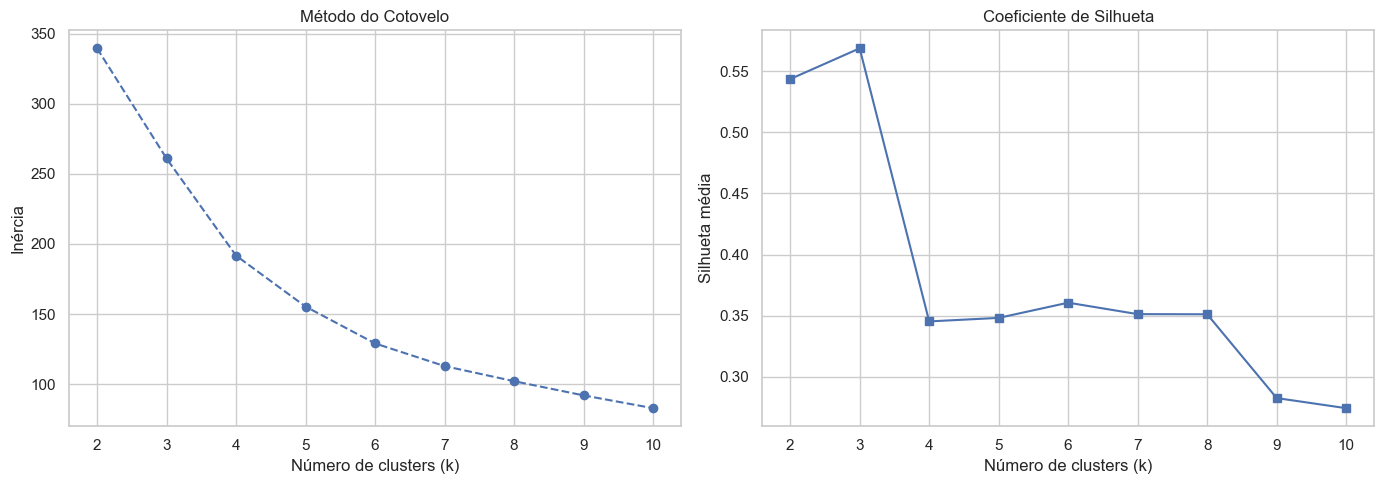

,k,inercia,silhueta
0,2,339.56,0.54
1,3,260.98,0.57
2,4,191.68,0.35
3,5,155.33,0.35
4,6,129.04,0.36
5,7,112.88,0.35
6,8,102.09,0.35
7,9,91.97,0.28
8,10,82.85,0.27


In [11]:
matriz_kmeans = df_modelo_escalado[colunas_modelagem]

valores_k = list(range(2, 11))
inercia = []
silhueta = []

for numero_clusters in valores_k:
    modelo_k = KMeans(
        n_clusters=numero_clusters,
        random_state=SEMENTE_ALEATORIA,
        n_init=20,
    )
    rotulos_k = modelo_k.fit_predict(matriz_kmeans)
    inercia.append(modelo_k.inertia_)
    silhueta.append(silhouette_score(matriz_kmeans, rotulos_k))

resultados_k = pd.DataFrame(
    {
        "k": valores_k,
        "inercia": inercia,
        "silhueta": silhueta,
    }
)

figura, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].plot(resultados_k["k"], resultados_k["inercia"], marker="o", linestyle="--")
eixos[0].set_title("Método do Cotovelo")
eixos[0].set_xlabel("Número de clusters (k)")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(resultados_k["k"], resultados_k["silhueta"], marker="s")
eixos[1].set_title("Coeficiente de Silhueta")
eixos[1].set_xlabel("Número de clusters (k)")
eixos[1].set_ylabel("Silhueta média")

plt.tight_layout()
plt.show()

resultados_k

## 7.2 Modelo final e perfil dos clusters

Com base nas métricas anteriores, ajusta-se o modelo final de K-Means e descrevem-se os perfis médios das unidades em cada cluster, permitindo uma leitura substantiva dos agrupamentos encontrados.

In [12]:
k_clusters = 3
modelo_kmeans = KMeans(
    n_clusters=k_clusters,
    random_state=SEMENTE_ALEATORIA,
    n_init=20,
)
rotulos_clusters = modelo_kmeans.fit_predict(matriz_kmeans)

df_unidades_saude["cluster"] = rotulos_clusters
df_modelo_escalado["cluster"] = rotulos_clusters

perfil_clusters = (
    df_unidades_saude.groupby("cluster")
    .agg(
        quantidade_unidades=("CO_CNES", "count"),
        media_escore_saudavel=("media_escore_saudavel", "mean"),
        media_idade=("media_idade", "mean"),
        proporcao_mulheres=("proporcao_mulheres", "mean"),
        media_total_atendimentos=("total_atendimentos", "mean"),
    )
    .round(2)
    .sort_index()
)

print("O valor final de k foi fixado em 3 com base na inspeção conjunta da inércia e da silhueta.")
perfil_clusters

O valor final de k foi fixado em 3 com base na inspeção conjunta da inércia e da silhueta.


,quantidade_unidades,media_escore_saudavel,media_idade,proporcao_mulheres,media_total_atendimentos
cluster,,,,,
0,154,5.28,27.00,0.69,746.34
1,20,4.50,50.74,0.93,56.00
2,2,7.07,31.66,0.01,176.50


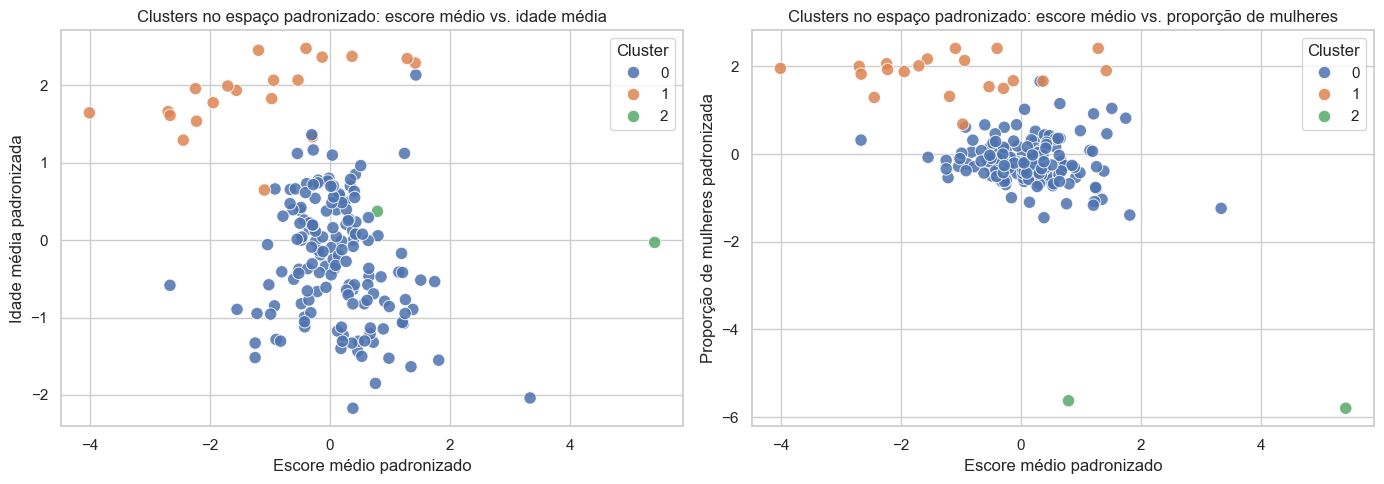

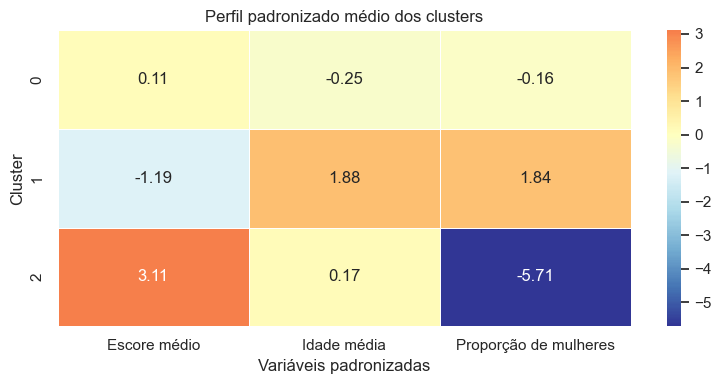

In [13]:
figura, eixos = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_modelo_escalado,
    x="media_escore_saudavel",
    y="media_idade",
    hue="cluster",
    palette=PALETA_CLUSTERS,
    s=80,
    alpha=0.85,
    ax=eixos[0],
)
eixos[0].set_title("Clusters no espaço padronizado: escore médio vs. idade média")
eixos[0].set_xlabel("Escore médio padronizado")
eixos[0].set_ylabel("Idade média padronizada")

sns.scatterplot(
    data=df_modelo_escalado,
    x="media_escore_saudavel",
    y="proporcao_mulheres",
    hue="cluster",
    palette=PALETA_CLUSTERS,
    s=80,
    alpha=0.85,
    ax=eixos[1],
)
eixos[1].set_title("Clusters no espaço padronizado: escore médio vs. proporção de mulheres")
eixos[1].set_xlabel("Escore médio padronizado")
eixos[1].set_ylabel("Proporção de mulheres padronizada")

for eixo in eixos:
    eixo.legend(title="Cluster")

plt.tight_layout()
plt.show()

perfil_padronizado_clusters = (
    df_modelo_escalado.groupby("cluster")[colunas_modelagem]
    .mean()
    .rename(
        columns={
            "media_escore_saudavel": "Escore médio",
            "media_idade": "Idade média",
            "proporcao_mulheres": "Proporção de mulheres",
        }
    )
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    perfil_padronizado_clusters,
    annot=True,
    cmap="RdYlBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Perfil padronizado médio dos clusters")
plt.xlabel("Variáveis padronizadas")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## 7.3 Distribuição geográfica das unidades de saúde

Além da separação observada no espaço padronizado das variáveis, é útil examinar como as unidades se distribuem territorialmente no Recife. Os mapas a seguir têm duas funções complementares: primeiro, mostrar a cobertura espacial das unidades incluídas na análise; segundo, verificar se os clusters identificados apresentam algum padrão geográfico visível no município.

Os mapas interativos permitem examinar com mais detalhe a localização das unidades, seus bairros e sua distribuição espacial por cluster. Essa visualização aprofunda a leitura territorial dos resultados sem alterar o fato de que os clusters foram definidos a partir de variáveis sintéticas padronizadas, e não por proximidade geográfica.

In [14]:
CAMINHO_COORDENADAS_RECIFE = Path("data/cnes_coordenadas_recife.csv")

if CAMINHO_COORDENADAS_RECIFE.exists():
    df_coordenadas_recife = pd.read_csv(CAMINHO_COORDENADAS_RECIFE)
else:
    caminho_dataset_coordenadas = Path(
        kagglehub.dataset_download(
            "diacbernardortura/estabelecimentos-do-cnes-coordenadas-geogrficas"
        )
    )
    caminho_csv_coordenadas = caminho_dataset_coordenadas / "cnes_coord.csv"

    df_coordenadas_recife = pd.read_csv(
        caminho_csv_coordenadas,
        usecols=[
            "co_ibge",
            "co_cnes",
            "endereco_completo",
            "no_logradouro",
            "nu_endereco",
            "no_bairro",
            "co_cep",
            "municipio",
            "uf",
            "lat",
            "long",
        ],
    )
    df_coordenadas_recife = df_coordenadas_recife.loc[
        (df_coordenadas_recife["municipio"].astype("string").str.upper() == "RECIFE")
        & (df_coordenadas_recife["uf"].astype("string").str.upper() == "PE")
    ].copy()
    df_coordenadas_recife.to_csv(CAMINHO_COORDENADAS_RECIFE, index=False)

df_coordenadas_recife["co_cnes"] = pd.to_numeric(
    df_coordenadas_recife["co_cnes"], errors="coerce"
).astype("Int64")
df_coordenadas_recife["lat"] = pd.to_numeric(df_coordenadas_recife["lat"], errors="coerce")
df_coordenadas_recife["long"] = pd.to_numeric(df_coordenadas_recife["long"], errors="coerce")

df_mapa_unidades = df_unidades_saude.copy()
df_mapa_unidades["CO_CNES"] = pd.to_numeric(
    df_mapa_unidades["CO_CNES"], errors="coerce"
).astype("Int64")

df_mapa_unidades = df_mapa_unidades.merge(
    df_coordenadas_recife.drop_duplicates(subset=["co_cnes"]),
    left_on="CO_CNES",
    right_on="co_cnes",
    how="left",
)
df_mapa_unidades = df_mapa_unidades.dropna(subset=["lat", "long"]).copy()

print(f"Unidades com coordenadas disponíveis: {len(df_mapa_unidades)}")
print(f"Unidades sem coordenadas: {len(df_unidades_saude) - len(df_mapa_unidades)}")

Unidades com coordenadas disponíveis: 176
Unidades sem coordenadas: 0


In [15]:
df_mapa_unidades["cluster_cat"] = "Cluster " + df_mapa_unidades["cluster"].astype(str)
df_mapa_unidades["cnes_hover"] = "CNES " + df_mapa_unidades["CO_CNES"].astype(str)

centro_recife = {"lat": float(df_mapa_unidades["lat"].mean()), "lon": float(df_mapa_unidades["long"].mean())}

fig_mapa_unidades = px.scatter_map(
    df_mapa_unidades,
    lat="lat",
    lon="long",
    hover_name="cnes_hover",
    hover_data={
        "cluster": False,
        "cluster_cat": False,
        "lat": ":.5f",
        "long": ":.5f",
        "no_bairro": True,
        "endereco_completo": True,
    },
    zoom=11,
    center=centro_recife,
    map_style="open-street-map",
    title="Distribuição espacial das unidades de saúde incluídas na análise",
)
fig_mapa_unidades.update_traces(marker={"size": 10, "color": "#4C72B0", "opacity": 0.75})
fig_mapa_unidades.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0}, height=550)
fig_mapa_unidades.show()

fig_mapa_clusters = px.scatter_map(
    df_mapa_unidades,
    lat="lat",
    lon="long",
    color="cluster_cat",
    hover_name="cnes_hover",
    hover_data={
        "cluster_cat": True,
        "lat": ":.5f",
        "long": ":.5f",
        "no_bairro": True,
        "endereco_completo": True,
    },
    color_discrete_map=PALETA_CLUSTERS_PLOTLY,
    zoom=11,
    center=centro_recife,
    map_style="open-street-map",
    title="Distribuição espacial dos clusters das unidades de saúde",
)
fig_mapa_clusters.update_traces(marker={"size": 11, "opacity": 0.80})
fig_mapa_clusters.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0}, height=550, legend_title_text="Cluster")
fig_mapa_clusters.show()

Distribuição das unidades por cluster:
cluster
0    154
1     20
2      2
Name: count, dtype: int64

Clusters excluídos da inferência por tamanho insuficiente (< 5 unidades): 2


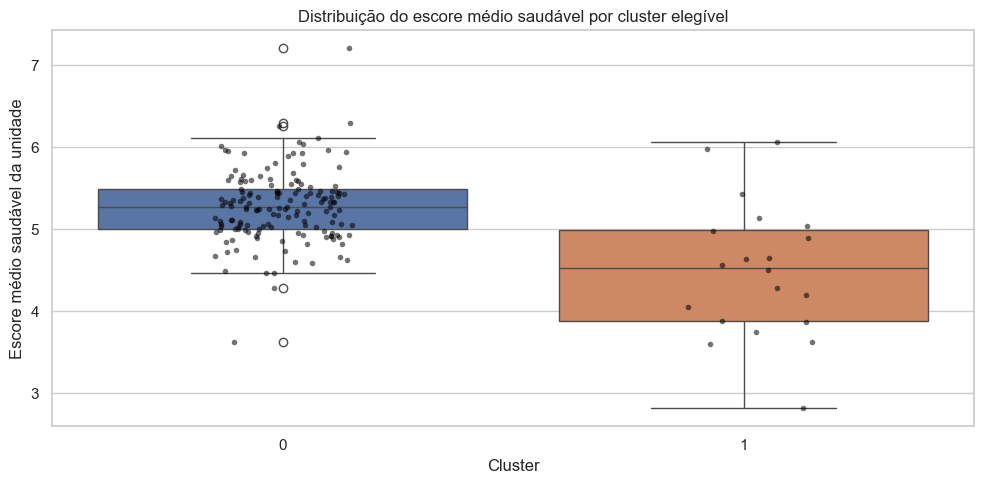


Teste de normalidade de Shapiro-Wilk por cluster elegível:
Cluster 0: n=154, W=0.9653, p-valor=0.0006
Cluster 1: n=20, W=0.9799, p-valor=0.9331

Resultados globais dos testes:
Levene: estatística=17.9026, p-valor=0.0000
ANOVA: estatística F=45.0911, p-valor=2.6303e-10
Kruskal-Wallis: estatística H=20.1351, p-valor=7.2161e-06
Eta-quadrado da ANOVA: 0.2077

Pós-teste de Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     0      1  -0.7822   0.0 -1.0121 -0.5522   True
---------------------------------------------------

Conclusão: há evidência de diferença estatisticamente significativa entre os clusters elegíveis. Essa evidência deve ser interpretada com cautela porque o escore médio também participa da formação dos grupos.


In [16]:
contagem_clusters = df_unidades_saude["cluster"].value_counts().sort_index()
clusters_elegiveis = contagem_clusters[contagem_clusters >= 5].index.tolist()
clusters_excluidos = contagem_clusters[contagem_clusters < 5].index.tolist()

df_inferencia = df_unidades_saude.loc[
    df_unidades_saude["cluster"].isin(clusters_elegiveis)
].copy()
variavel_resposta = "media_escore_saudavel"
grupo_inferencia = df_inferencia.groupby("cluster")[variavel_resposta]
series_grupos = [serie for _, serie in grupo_inferencia]

print("Distribuição das unidades por cluster:")
print(contagem_clusters)

if clusters_excluidos:
    print(
        "\nClusters excluídos da inferência por tamanho insuficiente (< 5 unidades): "
        + ", ".join(map(str, clusters_excluidos))
    )

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_inferencia,
    x="cluster",
    y=variavel_resposta,
    hue="cluster",
    palette=PALETA_CLUSTERS,
    dodge=False,
    legend=False,
)
sns.stripplot(
    data=df_inferencia,
    x="cluster",
    y=variavel_resposta,
    color="black",
    size=4,
    alpha=0.55,
    jitter=0.15,
)
plt.title("Distribuição do escore médio saudável por cluster elegível")
plt.xlabel("Cluster")
plt.ylabel("Escore médio saudável da unidade")
plt.tight_layout()
plt.show()

print("\nTeste de normalidade de Shapiro-Wilk por cluster elegível:")
for cluster, serie in grupo_inferencia:
    estatistica_shapiro, p_shapiro = stats.shapiro(serie)
    print(
        f"Cluster {cluster}: n={len(serie)}, W={estatistica_shapiro:.4f}, p-valor={p_shapiro:.4f}"
    )

estatistica_levene, p_levene = stats.levene(*series_grupos)
estatistica_anova, p_anova = stats.f_oneway(*series_grupos)
estatistica_kruskal, p_kruskal = stats.kruskal(*series_grupos)

numero_grupos = len(series_grupos)
numero_observacoes = len(df_inferencia)
eta_quadrado = (
    (estatistica_anova * (numero_grupos - 1))
    / ((estatistica_anova * (numero_grupos - 1)) + (numero_observacoes - numero_grupos))
)

print("\nResultados globais dos testes:")
print(f"Levene: estatística={estatistica_levene:.4f}, p-valor={p_levene:.4f}")
print(f"ANOVA: estatística F={estatistica_anova:.4f}, p-valor={p_anova:.4e}")
print(f"Kruskal-Wallis: estatística H={estatistica_kruskal:.4f}, p-valor={p_kruskal:.4e}")
print(f"Eta-quadrado da ANOVA: {eta_quadrado:.4f}")

resultado_tukey = pairwise_tukeyhsd(
    endog=df_inferencia[variavel_resposta],
    groups=df_inferencia["cluster"].astype(str),
    alpha=0.05,
)

print("\nPós-teste de Tukey HSD:")
print(resultado_tukey)

if p_kruskal < 0.05:
    print(
        "\nConclusão: há evidência de diferença estatisticamente significativa entre os clusters elegíveis. "
        "Essa evidência deve ser interpretada com cautela porque o escore médio também participa da formação dos grupos."
    )
else:
    print(
        "\nConclusão: não houve evidência suficiente para rejeitar a hipótese nula entre os clusters elegíveis."
    )

## 9. Considerações Finais

Os resultados sugerem que as unidades de saúde do Recife não constituem um conjunto homogêneo quando resumidas por escore nutricional médio, idade média e proporção de mulheres atendidas. A clusterização permitiu organizar essa heterogeneidade em grupos com características relativamente semelhantes internamente, enquanto os testes inferenciais ofereceram evidência formal de diferença entre os clusters elegíveis.

Do ponto de vista substantivo, o notebook mostra como os microdados do SISVAN podem ser convertidos em indicadores úteis para análise territorial e organizacional da atenção primária. Do ponto de vista metodológico, o fluxo construído integra preparação de dados, síntese de informação, modelagem não supervisionada e inferência estatística em uma única sequência analítica, favorecendo transparência, reprodutibilidade e clareza interpretativa.